# Zgodność anotatorów i statystyki zbioru (PolEmo, 3 anotatorów)

**Przebieg eksperymentu**

| Etap | Dane | Instrukcja |
|---|---|---|
| Iteracja 1 | `sample1` (te same teksty dla wszystkich) | wytyczne v1 |
| Iteracja 2 | `sample2` (nowe teksty, te same dla wszystkich) | wytyczne v2 (uszczegółowione) |
| Zbiór docelowy | `sample_<imię>` (rozłączne teksty dla każdego) | wytyczne v2 |

Anotacje: wydźwięk całego tekstu (`plus_m`, `minus_m`, `zero`, `amb`) oraz fragmenty (`wzmocnienie`, `oslabienie`, `negacja`).
Eksporty z Label Studio (JSON) leżą w `annotation/<próbka>/export_<imię>.json`, a oryginalne etykiety PolEmo (gold) w `gold_<próbka>.json` (tylko lokalnie, poza repo).

**Plan notebooka**
1. Zgodność między anotatorami: iteracja 1 vs 2 (kappa Cohena i Fleissa, przedziały ufności, macierze pomyłek, fragmenty, czas).
2. Porównanie z gold.
3. Zmiana zgodności po uszczegółowieniu instrukcji.
4. Statystyki opisowe zbioru z niezależnych próbek anotatorów.

## 0. Konfiguracja i funkcje pomocnicze

### 0.1 Importy, stałe i interpretacja kappy

In [50]:
import json
import re
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

warnings.filterwarnings("ignore")  # kappa dla stałych etykiet daje NaN i ostrzeżenia
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 220)

ANNOT = Path("../annotation")
ANNOTATORS = ["mikolaj", "dominik", "piotrek"]
SENTIMENT = "sentiment"  # from_name z label_config.xml
SPANS = "spans"

LABELS = ["plus_m", "minus_m", "zero", "amb"]
MODS = ["wzmocnienie", "oslabienie", "negacja"]
ITERS = {"sample1": "Iteracja 1 (wytyczne v1)", "sample2": "Iteracja 2 (wytyczne v2)"}
LABEL_COLORS = dict(zip(LABELS, ["#2e7d32", "#c62828", "#757575", "#f9a825"]))
ITER_COLORS = dict(zip(ITERS.values(), ["#9e9e9e", "#1565c0"]))
ANN_COLORS = {**dict(zip(ANNOTATORS, sns.color_palette("Set2", 3))), "gold": "#424242"}


def interpret(k: float) -> str:
    if pd.isna(k):
        return "n/d"
    bands = [
        (0, "poniżej losowej"),
        (0.2, "nikła"),
        (0.4, "słaba"),
        (0.6, "umiarkowana"),
        (0.8, "dobra"),
        (1.01, "bardzo dobra"),
    ]
    return next(name for bound, name in bands if k < bound)


### 0.2 Wczytywanie eksportów Label Studio i etykiet gold

In [51]:
def load_export(path: Path, only_ids: set | None = None) -> dict[int, dict]:
    out = {}
    for task in json.loads(path.read_text(encoding="utf-8")):
        tid = task["data"]["id"]
        if only_ids is not None and tid not in only_ids:
            continue
        anns = [a for a in task.get("annotations", []) if not a.get("was_cancelled")]
        if not anns:
            continue
        sentiment, spans = None, []
        for res in anns[-1]["result"]:
            if res["from_name"] == SENTIMENT:
                sentiment = res["value"]["choices"][0]
            elif res["from_name"] == SPANS:
                v = res["value"]
                spans.append((v["start"], v["end"], v["labels"][0], v["text"]))
        out[tid] = {
            "text": task["data"]["text"],
            "sentiment": sentiment,
            "spans": spans,
            "lead_time": anns[-1].get("lead_time"),
        }
    return out


TOKEN = re.compile(r"\w+|[^\w\s]")


def token_labels(text: str, spans: list) -> list[str]:
    toks = list(TOKEN.finditer(text))
    labels = ["O"] * len(toks)
    for start, end, label, *_ in sorted(spans):
        for i, m in enumerate(toks):
            if m.start() < end and m.end() > start and labels[i] == "O":
                labels[i] = label
    return labels


def load_gold(folder: str, name: str) -> pd.Series:
    p = ANNOT / folder / f"gold_{name}.json"
    return pd.Series(
        {int(k): v.removeprefix("meta_") for k, v in json.loads(p.read_text()).items()}
    )


### 0.3 Miary zgodności (kappa Cohena i Fleissa)

In [52]:
def cohen_pairs(df: pd.DataFrame) -> dict[str, float]:
    return {
        f"{a}-{b}": cohen_kappa_score(df[a], df[b])
        for a, b in combinations(df.columns, 2)
    }


def fleiss(df: pd.DataFrame) -> float:
    table, _ = aggregate_raters(df.to_numpy())
    return fleiss_kappa(table, method="fleiss")


def summarize(text_df: pd.DataFrame, tok_df: pd.DataFrame) -> pd.DataFrame:
    active = tok_df[(tok_df != "O").any(axis=1)]  # tokeny zaznaczone przez min. 1 osobę
    rows = {}
    for name, d in [
        ("cały tekst", text_df),
        ("fragmenty: wszystkie tokeny", tok_df),
        ("fragmenty: tokeny zaznaczone", active),
    ]:
        pairs = cohen_pairs(d)
        rows[name] = {
            **pairs,
            "Cohen (średnia)": np.mean(list(pairs.values())),
            "Fleiss": fleiss(d),
        }
    return pd.DataFrame(rows).T


def evaluate(iteration: str):
    data = {a: load_export(ANNOT / iteration / f"export_{a}.json") for a in ANNOTATORS}
    ids = sorted(set.intersection(*(set(d) for d in data.values())))
    text_df = pd.DataFrame(
        {a: [data[a][i]["sentiment"] for i in ids] for a in ANNOTATORS}, index=ids
    )
    tok = {a: [] for a in ANNOTATORS}
    for i in ids:
        for a in ANNOTATORS:
            tok[a] += token_labels(data[a][i]["text"], data[a][i]["spans"])
    tok_df = pd.DataFrame(tok)
    return data, text_df, tok_df


### 0.4 Funkcje pomocnicze (głosowanie, bootstrap, macierze pomyłek)

In [53]:
def majority(df: pd.DataFrame) -> pd.Series:
    def vote(row):
        vc = row.value_counts()
        return vc.index[0] if vc.iloc[0] >= 2 else np.nan  # NaN gdy 3 różne etykiety

    return df.apply(vote, axis=1)


def mean_cohen(df: pd.DataFrame) -> float:
    return float(np.mean(list(cohen_pairs(df).values())))


def bootstrap(df: pd.DataFrame, n: int = 1000, seed: int = 0) -> np.ndarray:
    # losowanie tekstów ze zwracaniem; kolumny: średni Cohen, Fleiss
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        s = df.iloc[rng.integers(0, len(df), len(df))]
        out.append((mean_cohen(s), fleiss(s)))
    return np.array(out)


def label_kappa(tok_df: pd.DataFrame, label: str) -> float:
    # zgodność binarna "token ma etykietę X", uśredniona po parach
    b = tok_df == label
    return float(
        np.nanmean(
            [cohen_kappa_score(b[x], b[y]) for x, y in combinations(b.columns, 2)]
        )
    )


def cohen_matrix(df: pd.DataFrame) -> pd.DataFrame:
    m = pd.DataFrame(1.0, index=df.columns, columns=df.columns)
    for a, b in combinations(df.columns, 2):
        m.loc[a, b] = m.loc[b, a] = cohen_kappa_score(df[a], df[b])
    return m


def pooled_confusion(df: pd.DataFrame) -> np.ndarray:
    cm = sum(
        confusion_matrix(df[a], df[b], labels=LABELS)
        for a, b in combinations(df.columns, 2)
    )
    return cm + cm.T


def add_bar_labels(ax, fmt: str = "%.2f") -> None:
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, fontsize=8, padding=2)


## 1. Zgodność między anotatorami: iteracja 1 vs 2

Każda iteracja to 10 tekstów anotowanych niezależnie przez trzy osoby. Przy tak małej próbce kappa jest bardzo niestabilna, więc obok wartości punktowych podajemy przedziały bootstrapowe i zwykłą procentową zgodność.

### 1.1 Wczytanie eksportów i podsumowanie kappy

In [54]:
RES, GOLD = {}, {}
for it in ITERS:
    data, text_df, tok_df = evaluate(it)
    RES[it] = dict(
        data=data, text=text_df, tok=tok_df, summary=summarize(text_df, tok_df)
    )
    GOLD[it] = load_gold(it, it).loc[text_df.index]
    print(f"{ITERS[it]}: {len(text_df)} tekstów, {len(tok_df)} tokenów")
    display(RES[it]["summary"].round(3))


Iteracja 1 (wytyczne v1): 10 tekstów, 930 tokenów


,mikolaj-dominik,mikolaj-piotrek,dominik-piotrek,Cohen (średnia),Fleiss
cały tekst,0.688,0.324,0.595,0.535,0.518
fragmenty: wszystkie tokeny,0.386,0.540,0.497,0.475,0.467
fragmenty: tokeny zaznaczone,0.084,0.361,0.271,0.238,0.199


Iteracja 2 (wytyczne v2): 10 tekstów, 1206 tokenów


,mikolaj-dominik,mikolaj-piotrek,dominik-piotrek,Cohen (średnia),Fleiss
cały tekst,1.000,0.865,0.865,0.910,0.910
fragmenty: wszystkie tokeny,0.531,0.437,0.647,0.538,0.535
fragmenty: tokeny zaznaczone,0.209,0.137,0.463,0.270,0.257


### 1.2 Kappa Cohena i Fleissa: iteracja 1 vs 2

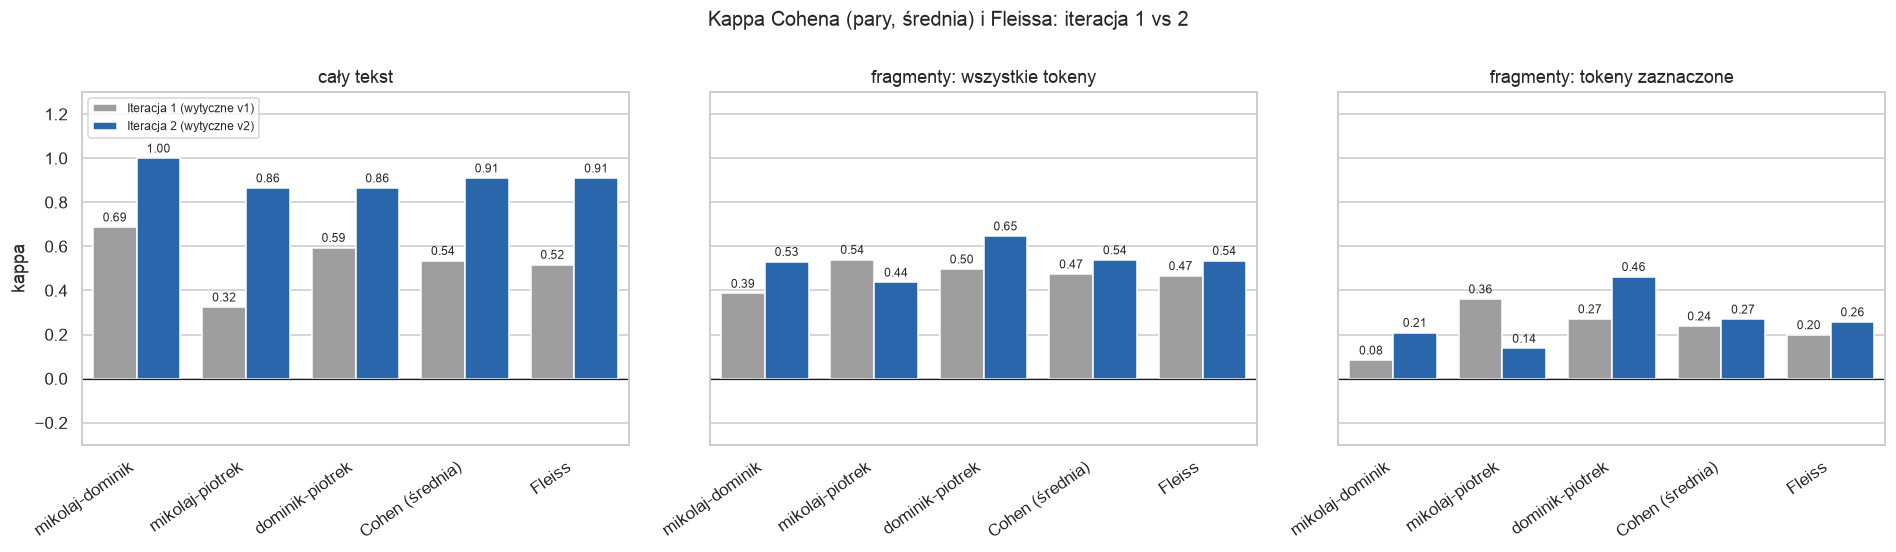

In [55]:
KL = pd.DataFrame(
    [
        (level, metric, ITERS[it], val)
        for it, r in RES.items()
        for level in r["summary"].index
        for metric, val in r["summary"].loc[level].items()
    ],
    columns=["poziom", "miara", "iteracja", "kappa"],
)
levels = list(KL["poziom"].unique())

fig, axes = plt.subplots(1, len(levels), figsize=(5.8 * len(levels), 5), sharey=True)
for ax, level in zip(axes, levels):
    d = KL[KL["poziom"] == level]
    sns.barplot(
        data=d, x="miara", y="kappa", hue="iteracja", palette=ITER_COLORS, ax=ax
    )
    add_bar_labels(ax)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(level)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].set_ylabel("kappa")
axes[0].set_ylim(min(-0.3, KL["kappa"].min() - 0.1), 1.3)  # miejsce na legendę
axes[0].legend(loc="upper left", fontsize=8, title="")
fig.suptitle(
    "Kappa Cohena (pary, średnia) i Fleissa: iteracja 1 vs 2", y=1.0, fontsize=13
)
plt.tight_layout()
plt.show()


### 1.3 Kto z kim się zgadza i które klasy są mylone (cały tekst)

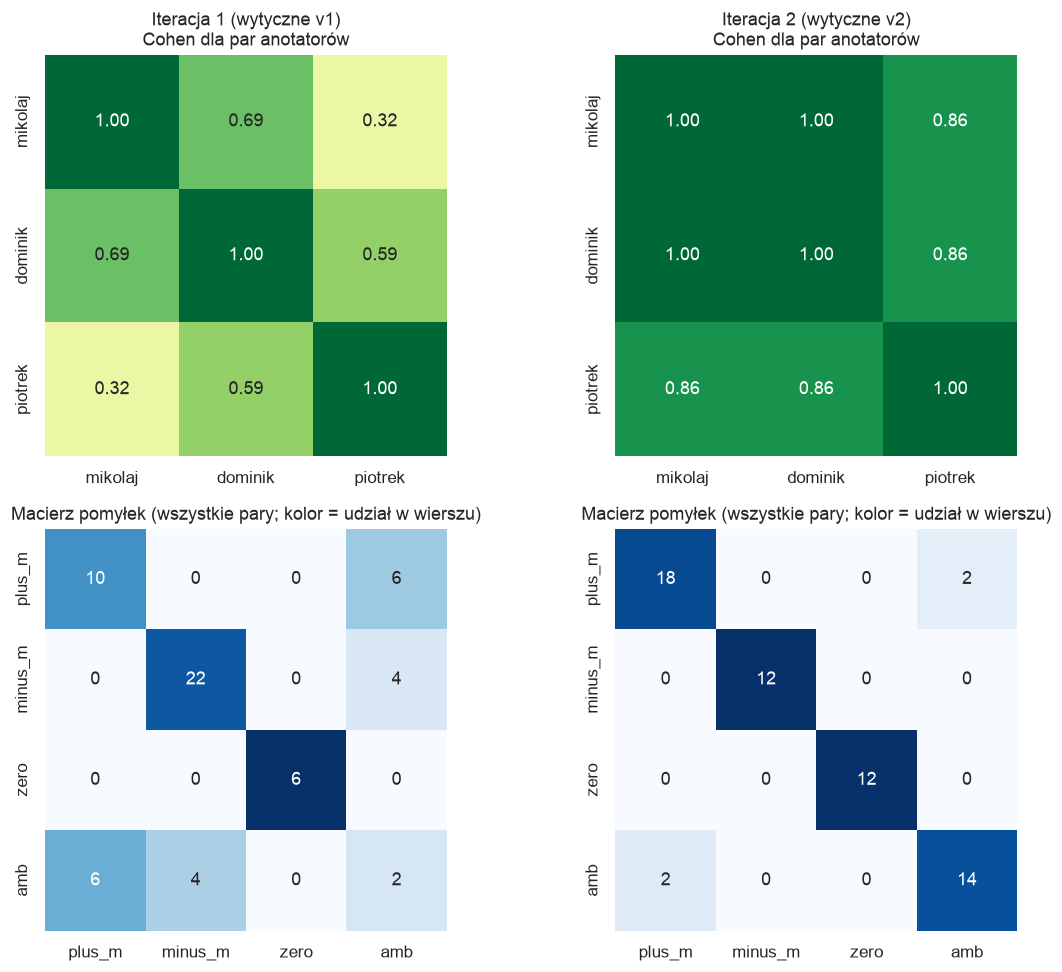

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for j, (it, r) in enumerate(RES.items()):
    sns.heatmap(
        cohen_matrix(r["text"]),
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=-0.5,
        vmax=1,
        ax=axes[0, j],
        cbar=False,
        square=True,
    )
    axes[0, j].set_title(f"{ITERS[it]}\nCohen dla par anotatorów")

    cm = pooled_confusion(r["text"])
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        norm,
        annot=cm,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=axes[1, j],
        xticklabels=LABELS,
        yticklabels=LABELS,
        cbar=False,
        square=True,
    )
    axes[1, j].set_title("Macierz pomyłek (wszystkie pary; kolor = udział w wierszu)")
plt.tight_layout()
plt.show()


### 1.4 Rozkład etykiet całego tekstu: każdy anotator vs gold

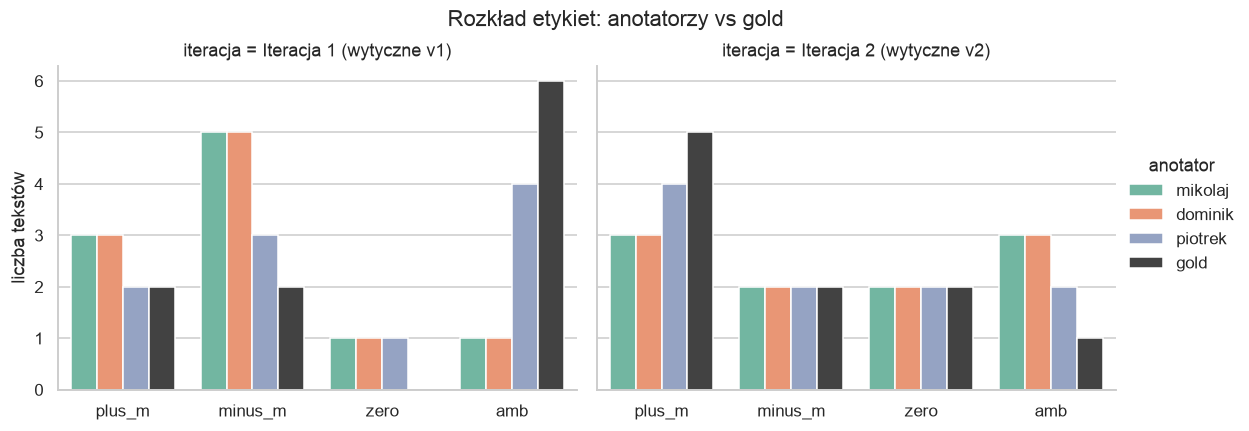

etykieta                           plus_m  minus_m  zero  amb
iteracja                 anotator                            
Iteracja 1 (wytyczne v1) dominik        3        5     1    1
                         gold           2        2     0    6
                         mikolaj        3        5     1    1
                         piotrek        2        3     1    4
Iteracja 2 (wytyczne v2) dominik        3        2     2    3
                         gold           5        2     2    1
                         mikolaj        3        2     2    3
                         piotrek        4        2     2    2

In [57]:
long = pd.concat(
    [
        r["text"]
        .assign(gold=GOLD[it])
        .rename_axis("id")
        .reset_index()
        .melt(id_vars="id", var_name="anotator", value_name="etykieta")
        .assign(iteracja=ITERS[it])
        for it, r in RES.items()
    ]
)
g = sns.catplot(
    data=long,
    x="etykieta",
    hue="anotator",
    col="iteracja",
    kind="count",
    order=LABELS,
    hue_order=ANNOTATORS + ["gold"],
    palette=ANN_COLORS,
    height=4,
    aspect=1.3,
)
g.set_axis_labels("", "liczba tekstów")
g.fig.suptitle("Rozkład etykiet: anotatorzy vs gold", y=1.03)
plt.show()
display(pd.crosstab([long["iteracja"], long["anotator"]], long["etykieta"])[LABELS])


### 1.5 Fragmenty: ile zaznaczono i jak bardzo anotatorzy zgadzają się co do konkretnych etykiet

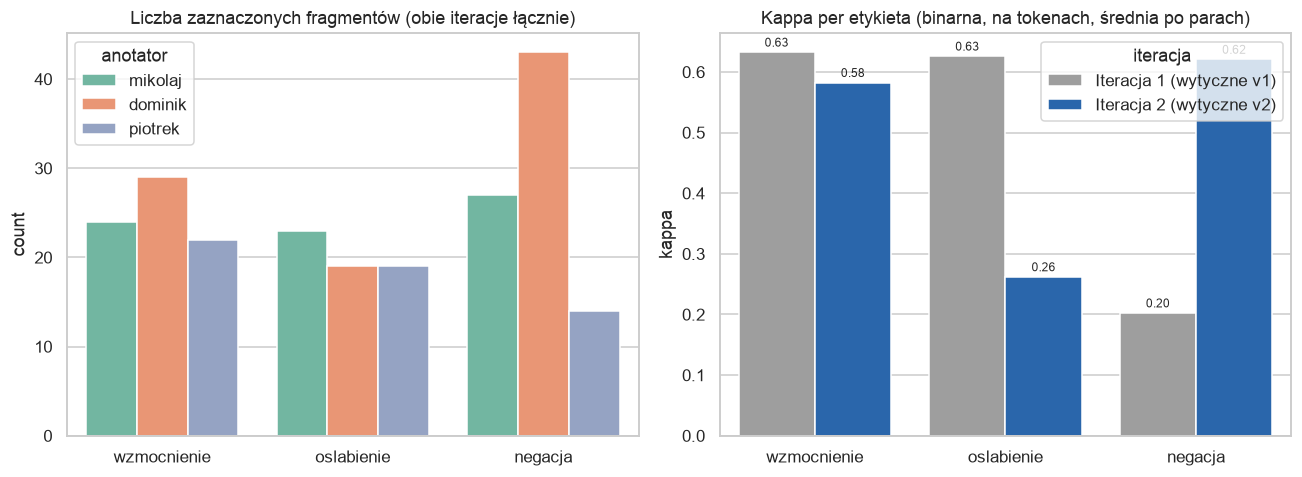

iteracja,Iteracja 1 (wytyczne v1),Iteracja 2 (wytyczne v2)
anotator,,
dominik,4.1,5.0
mikolaj,2.3,5.1
piotrek,2.1,3.4


etykieta                           wzmocnienie  oslabienie  negacja
iteracja                 anotator                                  
Iteracja 1 (wytyczne v1) dominik             8           8       25
                         mikolaj            11           9        3
                         piotrek             6          12        3
Iteracja 2 (wytyczne v2) dominik            21          11       18
                         mikolaj            13          14       24
                         piotrek            16           7       11

In [58]:
SP = pd.DataFrame(
    [
        dict(
            iteracja=ITERS[it],
            anotator=a,
            id=tid,
            etykieta=l,
            tekst=t.lower(),
            slowa=len(t.split()),
        )
        for it, r in RES.items()
        for a in ANNOTATORS
        for tid, d in r["data"][a].items()
        if tid in r["text"].index
        for _, _, l, t in d["spans"]
    ]
)
LK = pd.DataFrame(
    [
        dict(iteracja=ITERS[it], etykieta=m, kappa=label_kappa(r["tok"], m))
        for it, r in RES.items()
        for m in MODS
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(
    data=SP,
    x="etykieta",
    hue="anotator",
    order=MODS,
    hue_order=ANNOTATORS,
    palette=ANN_COLORS,
    ax=ax1,
)
ax1.set_title("Liczba zaznaczonych fragmentów (obie iteracje łącznie)")
ax1.set_xlabel("")
sns.barplot(
    data=LK, x="etykieta", y="kappa", hue="iteracja", palette=ITER_COLORS, ax=ax2
)
add_bar_labels(ax2)
ax2.axhline(0, color="k", lw=0.8)
ax2.set_title("Kappa per etykieta (binarna, na tokenach, średnia po parach)")
ax2.set_xlabel("")
plt.tight_layout()
plt.show()

n_texts = {ITERS[it]: len(r["text"]) for it, r in RES.items()}
cnt = SP.groupby(["iteracja", "anotator"]).size()
per_text = (cnt / cnt.index.get_level_values("iteracja").map(n_texts)).rename(
    "fragmentów na tekst"
)
display(per_text.round(2).unstack("iteracja"))
display(
    SP.pivot_table(
        index=["iteracja", "anotator"],
        columns="etykieta",
        values="id",
        aggfunc="count",
        fill_value=0,
    ).reindex(columns=MODS, fill_value=0)
)


### 1.6 Czas anotacji jednego tekstu (`lead_time` z Label Studio)

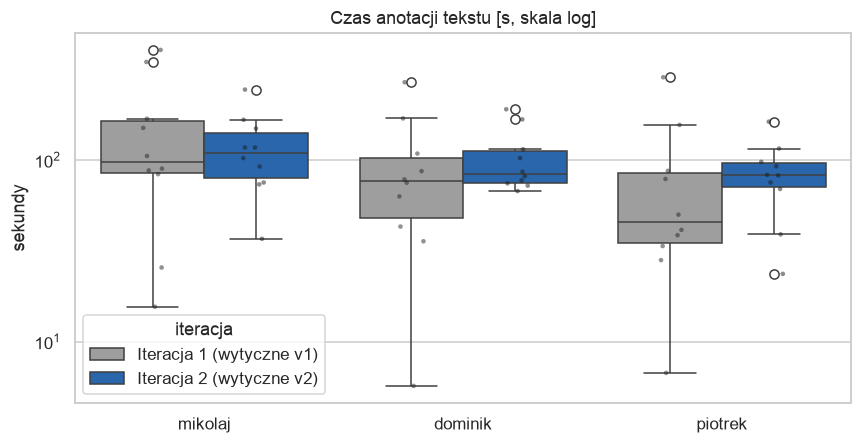

median                           \
iteracja Iteracja 1 (wytyczne v1) Iteracja 2 (wytyczne v2)   
anotator                                                     
dominik                      77.0                     84.0   
mikolaj                      98.0                    110.0   
piotrek                      46.0                     83.0   

                             mean                           \
iteracja Iteracja 1 (wytyczne v1) Iteracja 2 (wytyczne v2)   
anotator                                                     
dominik                      94.0                    104.0   
mikolaj                     148.0                    118.0   
piotrek                      81.0                     84.0   

                              sum                           
iteracja Iteracja 1 (wytyczne v1) Iteracja 2 (wytyczne v2)  
anotator                                                    
dominik                     936.0                   1036.0  
mikolaj                    1480.0                   1177.0  
piotrek                     808.0                    842.0

In [59]:
LT = pd.DataFrame(
    [
        dict(iteracja=ITERS[it], anotator=a, id=tid, sekundy=d["lead_time"])
        for it, r in RES.items()
        for a in ANNOTATORS
        for tid, d in r["data"][a].items()
        if tid in r["text"].index
    ]
)
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.boxplot(
    data=LT,
    x="anotator",
    y="sekundy",
    hue="iteracja",
    order=ANNOTATORS,
    palette=ITER_COLORS,
    ax=ax,
)
sns.stripplot(
    data=LT,
    x="anotator",
    y="sekundy",
    hue="iteracja",
    order=ANNOTATORS,
    dodge=True,
    color="k",
    size=3,
    alpha=0.5,
    ax=ax,
    legend=False,
)
ax.set_yscale("log")
ax.set_title("Czas anotacji tekstu [s, skala log]")
ax.set_xlabel("")
plt.tight_layout()
plt.show()
display(
    LT.groupby(["anotator", "iteracja"])["sekundy"]
    .agg(["median", "mean", "sum"])
    .round(0)
    .unstack("iteracja")
)


### 1.7 Teksty z rozbieżnościami do omówienia (z etykietą gold)

In [60]:
for it, r in RES.items():
    d = r["text"].assign(gold=GOLD[it])
    d["tekst"] = [r["data"][ANNOTATORS[0]][i]["text"][:220] for i in d.index]
    mask = r["text"].nunique(axis=1) > 1
    print(f"\n{ITERS[it]}: {mask.sum()} / {len(d)} tekstów z rozbieżnością")
    display(d[mask])



Iteracja 1 (wytyczne v1): 5 / 10 tekstów z rozbieżnością


,mikolaj,dominik,piotrek,gold,tekst
611,plus_m,plus_m,amb,amb,"na plus muszę zaliczyć położenie (idealne na nocleg tranzytowy) i śniadanie. Obsługa bardzo miła - na recepcji przywitał nas właściciel, a śniadanie podawała jego żona. Pewnym mankamentem jest brak restauracji w samy..."
1199,minus_m,minus_m,amb,amb,"Hotel 4 gwiazdkowy zbudowany chyba w latach 90 gdzie pojęcie wysokiej jakości czy luksusu odbiegało od teraźniejszości. Syntetycznie rzecz ujmując. Plusy: czystość, lokalizacja, wygodny materac, siłownia, śniadania. ..."
2498,plus_m,amb,amb,amb,"Cóż, w tej cenie nie ma co się spodziewać cudów, dźwięk jest, basy praktycznie zerowe co jednak można korektorem w karcie dźwiękowej podbić i wówczas brzmią nawet znośnie, choć jest czysto i w miarę przestrzennie to ..."
5255,amb,plus_m,plus_m,plus_m,"Trochę drogo, ale chyba lepiej wydać więcej pieniędzy, jeśli lekarz ma profesjonalne podejście do pacjenta, a tak jest w przypadku pani doktor. Chodziła m do dwóch innych ginekologów i żadna z pań nie zleciła mi bada..."
5668,minus_m,minus_m,amb,amb,"Pan doktor jest bardzo miły i delikatny przy badaniu, niestety odniosła m wrażenie, że nieco zbyt zapracowany, stąd ocena. Od razu przekazuje nr telefonu i zapewnia, że można dzwonić i pisać o każdej porze, więc w ra..."



Iteracja 2 (wytyczne v2): 1 / 10 tekstów z rozbieżnością


,mikolaj,dominik,piotrek,gold,tekst
2548,amb,amb,plus_m,plus_m,"ogólnie położenie hotelu super, maly minus że trzeba iść stromo pod górę od ulicy, piękna plaża choć kamienista trochę piachu się też znajdzie. obsługa hotelu miła i pomocna.jedyny minus to łazienki ale wiem że w tą ..."


## 2. Porównanie z gold (oryginalne etykiety PolEmo)

Gold to etykiety całych tekstów z korpusu (te same cztery klasy). Sprawdzamy, jak blisko korpusu są pojedynczy anotatorzy, ich głosowanie większościowe i czy zmiana instrukcji przybliżyła ich do gold.

### 2.1 Zgodność anotatorów i większości z gold

,iteracja,anotator,kappa,accuracy
0,Iteracja 1 (wytyczne v1),mikolaj,0.103,0.3
1,Iteracja 1 (wytyczne v1),dominik,0.359,0.5
2,Iteracja 1 (wytyczne v1),piotrek,0.697,0.8
3,Iteracja 1 (wytyczne v1),większość,0.359,0.5
4,Iteracja 2 (wytyczne v2),mikolaj,0.730,0.8
5,Iteracja 2 (wytyczne v2),dominik,0.730,0.8
6,Iteracja 2 (wytyczne v2),piotrek,0.857,0.9
7,Iteracja 2 (wytyczne v2),większość,0.730,0.8


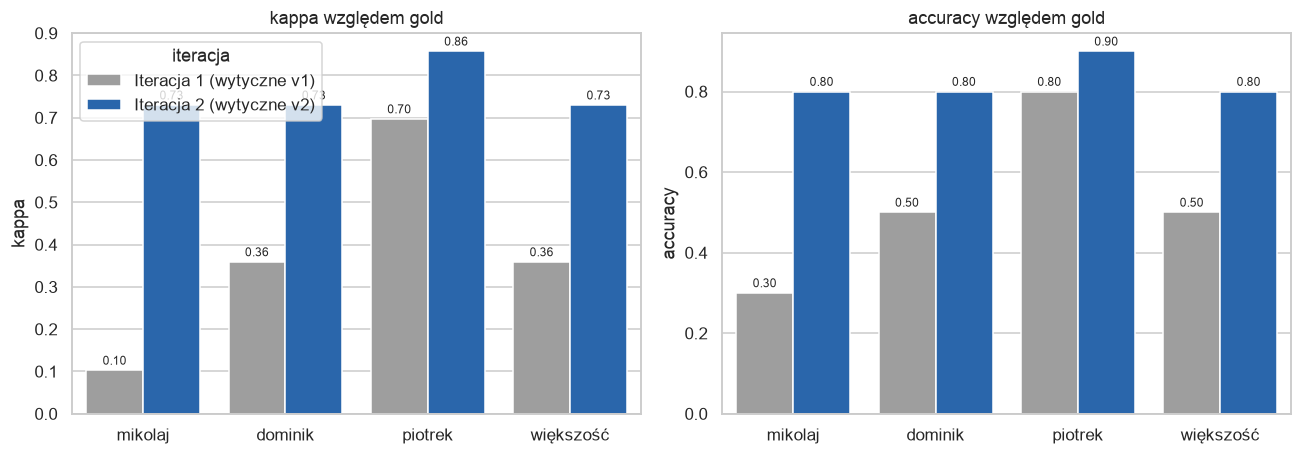

,Iteracja 1 (wytyczne v1),Iteracja 2 (wytyczne v2)
Fleiss (3 anotatorów),0.518,0.91
Fleiss (3 anotatorów + gold),0.430,0.84
bez większości (3 różne etykiety),0.000,0.00


In [61]:
rows = []
MV = {}
for it, r in RES.items():
    g = GOLD[it]
    for a in ANNOTATORS:
        rows.append(
            dict(
                iteracja=ITERS[it],
                anotator=a,
                kappa=cohen_kappa_score(r["text"][a], g),
                accuracy=accuracy_score(g, r["text"][a]),
            )
        )
    MV[it] = majority(r["text"])
    ok = MV[it].notna()
    rows.append(
        dict(
            iteracja=ITERS[it],
            anotator="większość",
            kappa=cohen_kappa_score(MV[it][ok], g[ok]),
            accuracy=accuracy_score(g[ok], MV[it][ok]),
        )
    )
VG = pd.DataFrame(rows)
display(VG.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, metric in zip(axes, ["kappa", "accuracy"]):
    sns.barplot(
        data=VG, x="anotator", y=metric, hue="iteracja", palette=ITER_COLORS, ax=ax
    )
    add_bar_labels(ax)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("")
    ax.set_title(f"{metric} względem gold")
    if ax is axes[1]:
        ax.get_legend().remove()
plt.tight_layout()
plt.show()

# czwarty "rater": gold
f4 = pd.DataFrame(
    {
        ITERS[it]: {
            "Fleiss (3 anotatorów)": fleiss(r["text"]),
            "Fleiss (3 anotatorów + gold)": fleiss(r["text"].assign(gold=GOLD[it])),
            "bez większości (3 różne etykiety)": int(MV[it].isna().sum()),
        }
        for it, r in RES.items()
    }
)
display(f4.round(3))


### 2.2 Gdzie anotatorzy (głosowanie większościowe) rozjeżdżają się z gold

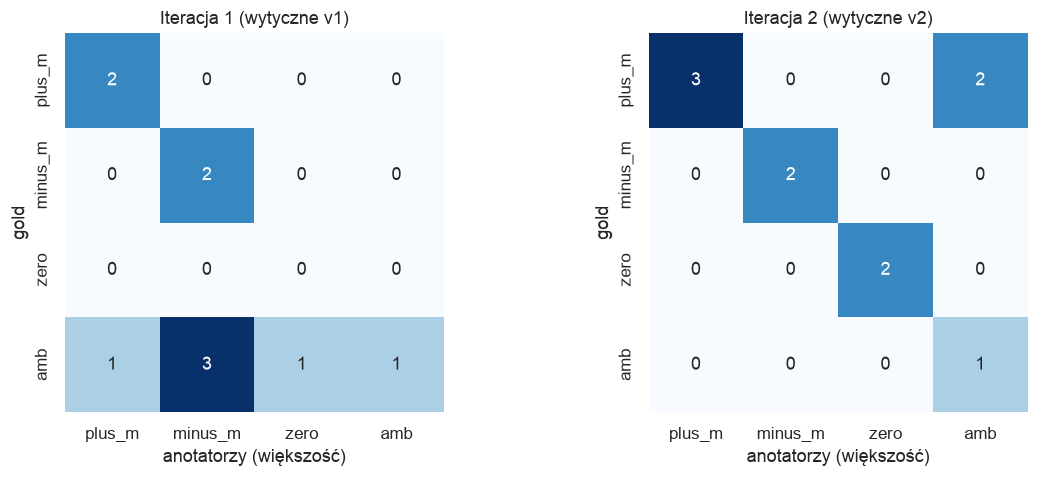


Iteracja 1 (wytyczne v1): 5 / 10 tekstów, w których większość ≠ gold


,mikolaj,dominik,piotrek,większość,gold,tekst
611,plus_m,plus_m,amb,plus_m,amb,"na plus muszę zaliczyć położenie (idealne na nocleg tranzytowy) i śniadanie. Obsługa bardzo miła - na recepcji przywitał nas właściciel, a śniadanie podawała jego żona. Pewnym mankamentem jest brak restauracji w samy..."
1042,zero,zero,zero,zero,amb,Fizyka H 1 (ćwiczenia) - - > dl a por
1199,minus_m,minus_m,amb,minus_m,amb,"Hotel 4 gwiazdkowy zbudowany chyba w latach 90 gdzie pojęcie wysokiej jakości czy luksusu odbiegało od teraźniejszości. Syntetycznie rzecz ujmując. Plusy: czystość, lokalizacja, wygodny materac, siłownia, śniadania. ..."
1468,minus_m,minus_m,minus_m,minus_m,amb,Hotel odbiega standardem od innych hoteli pięciogwiazdkowych. Pokoje wykazują ślady zużycia (wyposażenie z lat bodajże 90 - tych). Obsługa hotelu nie reagowała na uwagi - w apartamencie był wszak telewizor w części w...
5668,minus_m,minus_m,amb,minus_m,amb,"Pan doktor jest bardzo miły i delikatny przy badaniu, niestety odniosła m wrażenie, że nieco zbyt zapracowany, stąd ocena. Od razu przekazuje nr telefonu i zapewnia, że można dzwonić i pisać o każdej porze, więc w ra..."



Iteracja 2 (wytyczne v2): 2 / 10 tekstów, w których większość ≠ gold


,mikolaj,dominik,piotrek,większość,gold,tekst
1377,amb,amb,amb,amb,plus_m,Spędzili śmy dwie noce w starym skrzydle hotelu. Wystrój pokoi jest daleko od współczesnego. To pochodzi od sevenites. Ale były nieskazitelnie czyste. Łazienka odnowiona tylko meble przywróciły wspomnienia dzieciństw...
2548,amb,amb,plus_m,amb,plus_m,"ogólnie położenie hotelu super, maly minus że trzeba iść stromo pod górę od ulicy, piękna plaża choć kamienista trochę piachu się też znajdzie. obsługa hotelu miła i pomocna.jedyny minus to łazienki ale wiem że w tą ..."


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (it, r) in zip(axes, RES.items()):
    ok = MV[it].notna()
    cm = confusion_matrix(GOLD[it][ok], MV[it][ok], labels=LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=LABELS,
        yticklabels=LABELS,
        ax=ax,
    )
    ax.set_xlabel("anotatorzy (większość)")
    ax.set_ylabel("gold")
    ax.set_title(ITERS[it])
plt.tight_layout()
plt.show()

for it, r in RES.items():
    d = r["text"].assign(większość=MV[it], gold=GOLD[it])
    d["tekst"] = [r["data"][ANNOTATORS[0]][i]["text"][:220] for i in d.index]
    bad = d[d["większość"] != d["gold"]]
    print(f"\n{ITERS[it]}: {len(bad)} / {len(d)} tekstów, w których większość ≠ gold")
    display(bad)


## 3. Jak zmieniła się zgodność po uszczegółowieniu instrukcji

Zestawienie zgodności między anotatorami (kappa Cohena i Fleissa) oraz zgodności z gold, z interpretacją według skali Landisa i Kocha (<0 poniżej losowej, 0-0.2 nikła, 0.2-0.4 słaba, 0.4-0.6 umiarkowana, 0.6-0.8 dobra, >0.8 bardzo dobra).

### 3.1 Zestawienie zmian zgodności

,poziom,miara,iteracja 1,iteracja 2,Δ,interpretacja 1,interpretacja 2
0,cały tekst,Cohen (średnia),0.535,0.910,0.374,umiarkowana,bardzo dobra
1,cały tekst,Fleiss,0.518,0.910,0.392,umiarkowana,bardzo dobra
2,fragmenty: wszystkie tokeny,Cohen (średnia),0.475,0.538,0.064,umiarkowana,umiarkowana
3,fragmenty: wszystkie tokeny,Fleiss,0.467,0.535,0.069,umiarkowana,umiarkowana
4,fragmenty: tokeny zaznaczone,Cohen (średnia),0.238,0.270,0.031,słaba,słaba
5,fragmenty: tokeny zaznaczone,Fleiss,0.199,0.257,0.058,nikła,słaba
6,cały tekst vs gold,Cohen (średnia po anotatorach),0.386,0.772,0.386,słaba,dobra


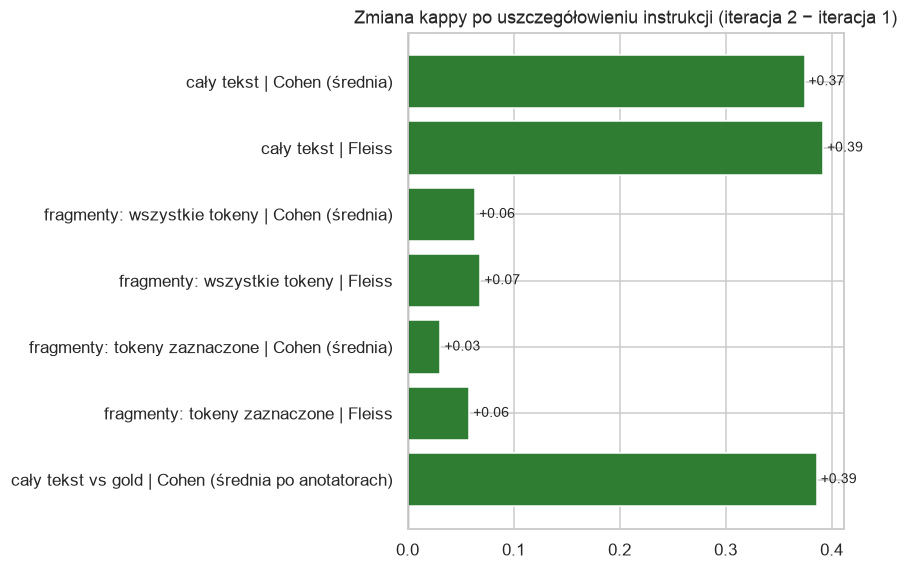

In [63]:
it1, it2 = ITERS
rows = []
for level in RES[it1]["summary"].index:
    for metric in ["Cohen (średnia)", "Fleiss"]:
        a, b = (RES[it]["summary"].loc[level, metric] for it in (it1, it2))
        rows.append(
            {
                "poziom": level,
                "miara": metric,
                "iteracja 1": a,
                "iteracja 2": b,
                "Δ": b - a,
                "interpretacja 1": interpret(a),
                "interpretacja 2": interpret(b),
            }
        )
a, b = (
    VG[(VG["iteracja"] == ITERS[it]) & VG["anotator"].isin(ANNOTATORS)]["kappa"].mean()
    for it in (it1, it2)
)
rows.append(
    {
        "poziom": "cały tekst vs gold",
        "miara": "Cohen (średnia po anotatorach)",
        "iteracja 1": a,
        "iteracja 2": b,
        "Δ": b - a,
        "interpretacja 1": interpret(a),
        "interpretacja 2": interpret(b),
    }
)
FINAL = pd.DataFrame(rows)
display(FINAL.round(3))

fig, ax = plt.subplots(figsize=(8, 0.55 * len(FINAL) + 1.5))
lbl = FINAL["poziom"] + " | " + FINAL["miara"]
ax.barh(lbl, FINAL["Δ"], color=np.where(FINAL["Δ"] >= 0, "#2e7d32", "#c62828"))
ax.axvline(0, color="k", lw=0.8)
for y, v in enumerate(FINAL["Δ"]):
    ax.text(
        v, y, f" {v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9
    )
ax.invert_yaxis()
ax.set_title("Zmiana kappy po uszczegółowieniu instrukcji (iteracja 2 − iteracja 1)")
plt.tight_layout()
plt.show()


### 3.2 Wnioski (zmiana po wytycznych v2)

Liczby poniżej opisują stan na pierwszych eksportach i trzeba je odświeżyć, jeśli dane się zmienią.

- **Cały tekst: wyraźna poprawa.** Fleiss 0,52 → 0,91, średni Cohen 0,54 → 0,91 (z „umiarkowanej" do „bardzo dobrej"). Pełną zgodność wszystkich trzech osób miało 50% tekstów w iteracji 1 i 90% w iteracji 2. Największy skok dotyczy pary mikolaj-piotrek (0,32 → 0,86).
- **Źródło rozbieżności.** W obu iteracjach wszystkie niezgodności dotyczą klasy `amb` (w iteracji 1 mylona z `plus_m` i `minus_m`, w iteracji 2 tylko z `plus_m`, w jednym tekście). Dodane przykłady i zasada o braku wyraźnej opinii zadziałały głównie na granicę `amb` vs reszta oraz `zero`.
- **Fragmenty: poprawa mała.** Kappa na wszystkich tokenach 0,47 → 0,54, a tylko na tokenach zaznaczonych przez min. jedną osobę 0,24 → 0,27 (Fleiss 0,20 → 0,26). Zgodność co do dokładnego zakresu fragmentu pozostaje słaba. Para mikolaj-piotrek się pogorszyła.
- **Per etykieta:** `negacja` poprawiła się najbardziej (0,20 → 0,62; w iteracji 1 jedna osoba zaznaczyła 25 negacji, pozostałe po 3), `wzmocnienie` pozostało stabilne (0,63 → 0,58), a `oslabienie` spadło (0,63 → 0,26). Możliwe wyjaśnienie: nowy przykład z „nawet" jako osłabieniem jest dyskusyjny. To hipoteza, którą warto sprawdzić przy wytycznych v3.
- **Zgodność z gold:** średnie kappa anotatorów vs gold 0,39 → 0,77, a trafność głosowania większościowego 0,5 → 0,8.


## 4. Zbiór z niezależnych próbek: statystyki opisowe

Każdy anotator oznaczył własne, rozłączne teksty (`sample_<imię>`), zgodnie z wytycznymi v2. Eksport z projektu zawiera też teksty z wcześniejszych iteracji, więc filtrujemy po `id` z pliku próbki. Dla każdego tekstu mamy etykietę anotatora, etykietę gold, fragmenty i czas anotacji.

### 4.1 Wczytanie próbek i przegląd zbioru

In [64]:
rows = []
for a in ANNOTATORS:
    folder = f"sample_{a}"
    ids = {
        t["data"]["id"]
        for t in json.loads((ANNOT / folder / f"{folder}.json").read_text())
    }
    exp = load_export(ANNOT / folder / f"export_{a}.json", only_ids=ids)
    gold = load_gold(folder, folder)
    if set(exp) != ids:
        print(f"{a}: brak anotacji dla {len(ids - set(exp))} tekstów")
    for tid, d in exp.items():
        sp = d["spans"]
        rows.append(
            dict(
                anotator=a,
                id=tid,
                text=d["text"],
                etykieta=d["sentiment"],
                gold=gold[tid],
                znaki=len(d["text"]),
                slowa=len(d["text"].split()),
                tokeny=len(TOKEN.findall(d["text"])),
                spany=len(sp),
                sekundy=d["lead_time"],
                lista_spanow=sp,
                **{f"n_{m}": sum(s[2] == m for s in sp) for m in MODS},
            )
        )
OWN = pd.DataFrame(rows)
OWN["zgodne_z_gold"] = OWN["etykieta"] == OWN["gold"]

overview = (
    OWN.groupby("anotator")
    .agg(
        teksty=("id", "count"),
        słowa_średnio=("slowa", "mean"),
        fragmenty_łącznie=("spany", "sum"),
        fragmenty_na_tekst=("spany", "mean"),
        czas_mediana_s=("sekundy", "median"),
        zgodność_z_gold=("zgodne_z_gold", "mean"),
    )
    .round(2)
)
overview.loc["razem"] = [
    len(OWN),
    OWN["slowa"].mean(),
    OWN["spany"].sum(),
    OWN["spany"].mean(),
    OWN["sekundy"].median(),
    OWN["zgodne_z_gold"].mean(),
]
display(overview.round(2))


,teksty,słowa_średnio,fragmenty_łącznie,fragmenty_na_tekst,czas_mediana_s,zgodność_z_gold
anotator,,,,,,
dominik,5.0,112.4,19.0,3.8,56.81,1.00
mikolaj,5.0,130.8,16.0,3.2,59.66,0.80
piotrek,5.0,109.0,19.0,3.8,40.38,0.80
razem,15.0,117.4,54.0,3.6,57.14,0.87


### 4.2 Rozkład etykiet: anotatorzy i gold tych samych tekstów

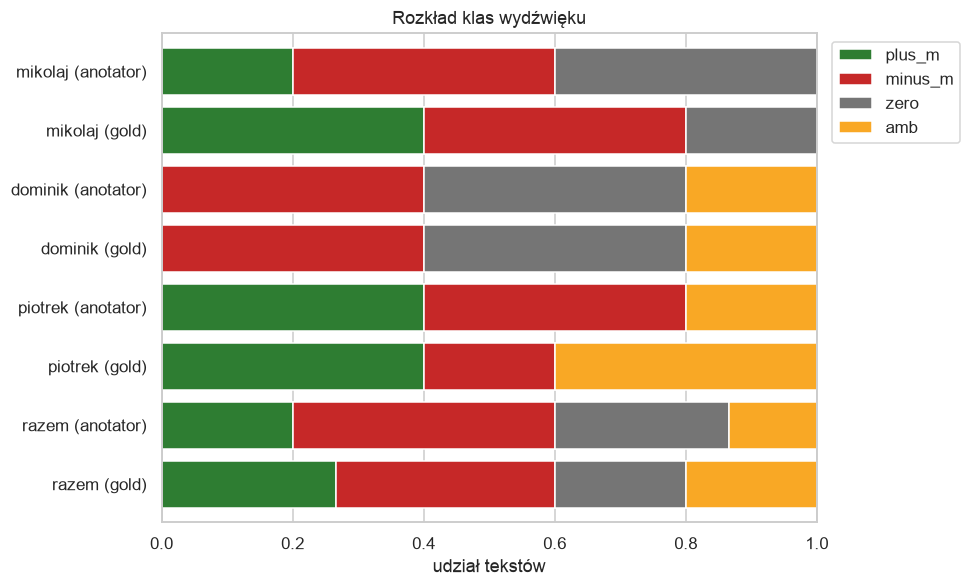

etykieta,plus_m,minus_m,zero,amb
anotator,,,,
dominik,0,2,2,1
mikolaj,1,2,2,0
piotrek,2,2,0,1
razem,3,6,4,2


,plus_m,minus_m,zero,amb
mikolaj (anotator),20.0,40.0,40.0,0.0
mikolaj (gold),40.0,40.0,20.0,0.0
dominik (anotator),0.0,40.0,40.0,20.0
dominik (gold),0.0,40.0,40.0,20.0
piotrek (anotator),40.0,40.0,0.0,20.0
piotrek (gold),40.0,20.0,0.0,40.0
razem (anotator),20.0,40.0,26.7,13.3
razem (gold),26.7,33.3,20.0,20.0


In [68]:
def share(s: pd.Series) -> pd.Series:
    return s.value_counts(normalize=True).reindex(LABELS, fill_value=0)


dist = {}
for a in ANNOTATORS:
    own = OWN[OWN["anotator"] == a]
    dist[f"{a} (anotator)"] = share(own["etykieta"])
    dist[f"{a} (gold)"] = share(own["gold"])
dist["razem (anotator)"] = share(OWN["etykieta"])
dist["razem (gold)"] = share(OWN["gold"])
D = pd.DataFrame(dist).T

ax = D.plot.barh(
    stacked=True, color=[LABEL_COLORS[l] for l in LABELS], figsize=(9, 5.5), width=0.8
)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("udział tekstów")
ax.set_title("Rozkład klas wydźwięku")
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

counts = pd.crosstab(OWN["anotator"], OWN["etykieta"]).reindex(
    columns=LABELS, fill_value=0
)
counts.loc["razem"] = counts.sum()
display(counts)
display((D * 100).round(1))


### 4.3 Fragmenty (modyfikatory) w zbiorze

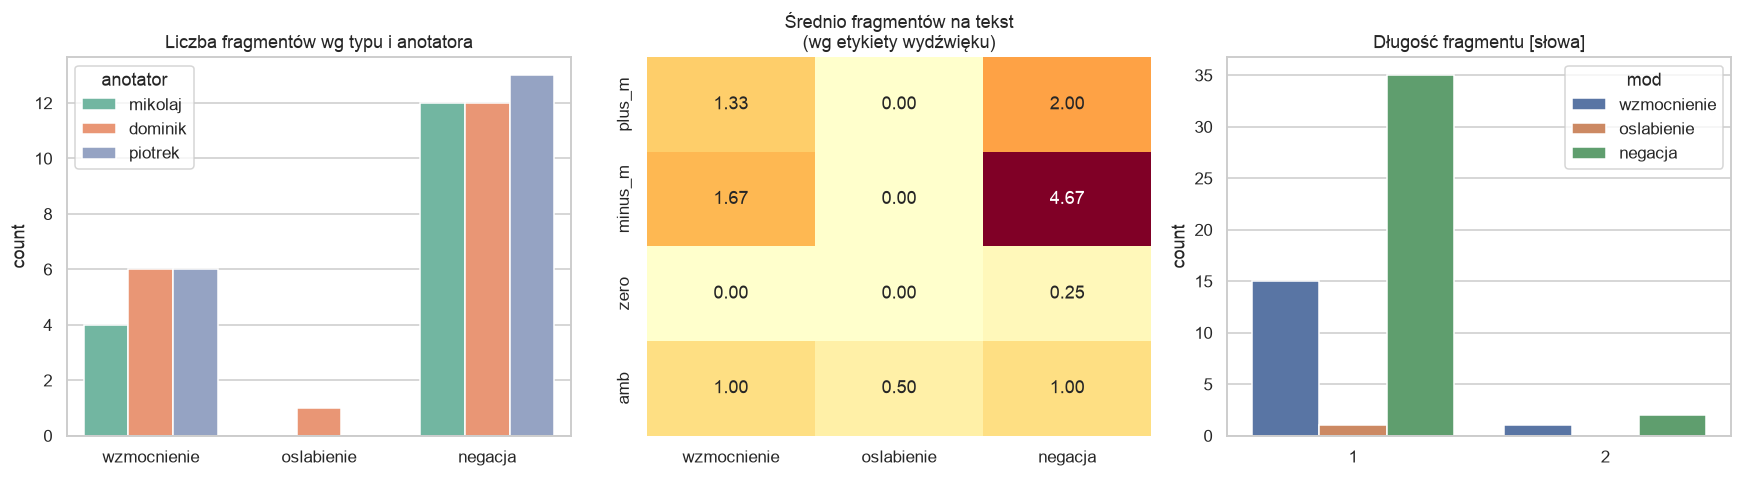

Teksty z co najmniej jednym fragmentem: 67%


,count,mean,std,min,25%,50%,75%,max
anotator,,,,,,,,
dominik,5.0,3.8,4.55,0.0,0.0,3.0,5.0,11.0
mikolaj,5.0,3.2,3.49,0.0,1.0,3.0,3.0,9.0
piotrek,5.0,3.8,4.49,0.0,0.0,2.0,7.0,10.0


,najczęstsze frazy
mod,
wzmocnienie,"bardzo (12), wielką (1), jeszcze bardziej (1), dużą (1), niezwykle (1)"
oslabienie,trochę (1)
negacja,"nie (26), nikt (3), niczego (1), mimo (1), natomiast (1), pomimo (1), brak jakiegokolwiek (1), zamiast (1)"


In [66]:
OS = OWN.explode("lista_spanow").dropna(subset=["lista_spanow"])
OS = OS.assign(
    mod=OS["lista_spanow"].map(lambda s: s[2]),
    fraza=OS["lista_spanow"].map(lambda s: s[3].lower()),
    dl=OS["lista_spanow"].map(lambda s: len(s[3].split())),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(
    data=OS,
    x="mod",
    hue="anotator",
    order=MODS,
    hue_order=ANNOTATORS,
    palette=ANN_COLORS,
    ax=axes[0],
)
axes[0].set_title("Liczba fragmentów wg typu i anotatora")
axes[0].set_xlabel("")

heat = OWN.groupby("etykieta")[[f"n_{m}" for m in MODS]].mean().reindex(LABELS)
heat.columns = MODS
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], cbar=False)
axes[1].set_title("Średnio fragmentów na tekst\n(wg etykiety wydźwięku)")
axes[1].set_ylabel("")

sns.countplot(data=OS, x="dl", hue="mod", hue_order=MODS, ax=axes[2])
axes[2].set_title("Długość fragmentu [słowa]")
axes[2].set_xlabel("")
plt.tight_layout()
plt.show()

print(f"Teksty z co najmniej jednym fragmentem: {(OWN['spany'] > 0).mean():.0%}")
display(OWN.groupby("anotator")["spany"].describe().round(2))
top = OS.groupby("mod")["fraza"].agg(
    lambda s: ", ".join(f"{w} ({c})" for w, c in s.value_counts().head(8).items())
)
display(top.reindex(MODS).to_frame("najczęstsze frazy"))


### 4.4 Jakość względem gold

In [67]:
quality = pd.DataFrame(
    {
        a: dict(
            accuracy=accuracy_score(d["gold"], d["etykieta"]),
            kappa_vs_gold=cohen_kappa_score(d["gold"], d["etykieta"]),
            sekundy_na_100_słów=100 * d["sekundy"].sum() / d["slowa"].sum(),
        )
        for a, d in OWN.groupby("anotator")
    }
).T
quality.loc["razem"] = [
    accuracy_score(OWN["gold"], OWN["etykieta"]),
    cohen_kappa_score(OWN["gold"], OWN["etykieta"]),
    100 * OWN["sekundy"].sum() / OWN["slowa"].sum(),
]
display(quality.round(2))
bad = OWN[~OWN["zgodne_z_gold"]][["anotator", "id", "etykieta", "gold", "text"]].assign(
    text=lambda d: d["text"].str[:220]
)
print(f"{len(bad)} / {len(OWN)} tekstów różni się od gold")
display(bad)


,accuracy,kappa_vs_gold,sekundy_na_100_słów
dominik,1.00,1.00,54.39
mikolaj,0.80,0.71,65.17
piotrek,0.80,0.71,53.63
razem,0.87,0.82,58.16


2 / 15 tekstów różni się od gold


,anotator,id,etykieta,gold,text
2,mikolaj,3892,zero,plus_m,"Jestem lekarzem i matką chłopca chorego na przewlekłą chorobę, któremu pan profesor uratował życie, a potem wielokrotnie udzielał cennych wskazówek dotyczących leczenia, gdy inni rozkładali ręce. Z jego wiedzy i goto..."
10,piotrek,2705,minus_m,amb,"Przyznaję, że pani Ewelina jest empatyczną osobą. Natomiast po konsultacjach z 3 psychologami mogę stwierdzić, że nie został em zdiagnozowany do końca pomimo 2 letniej terapii. Została pominięta jedna najbardziej uci..."


### 4.5 Podsumowanie zbioru (niezależne próbki)

Liczby opisują stan na pierwszych eksportach (5 tekstów na osobę).

- **Rozmiar:** 15 tekstów (po 5 na anotatora), 54 zaznaczone fragmenty (3,6 na tekst), 67% tekstów ma co najmniej jeden fragment.
- **Długość:** średnio 117 słów (mediana 94, zakres 48-303), więc teksty są długie i mocno skośne w prawo. Najdłuższe są teksty `minus_m`, a `amb` w tej próbce bardzo krótkie.
- **Rozkład klas** (anotatorzy / gold): `plus_m` 20% / 27%, `minus_m` 40% / 33%, `zero` 27% / 20%, `amb` 13% / 20%. Anotatorzy rzadziej niż gold wybierali `amb` i częściej `zero`, ale przy 15 tekstach różnice nie są istotne.
- **Zgodność z gold:** accuracy 0,87, kappa 0,82. Różnią się 2 teksty: `zero` zamiast `plus_m` (id 3892) oraz `minus_m` zamiast `amb` (id 2705). Znowu granica `amb` i wyraźnej opinii.
- **Fragmenty:** dominują `negacja` (głównie „nie") i `wzmocnienie` („bardzo"), a `oslabienie` jest bardzo rzadkie. Mało przykładów osłabienia tłumaczy niską zgodność tej etykiety i warto to doprecyzować w wytycznych.
- **Czas:** mediana około 57 s na tekst, około 58 s na 100 słów. Piotrek jest najszybszy, mikolaj najwolniejszy (zakresy mocno się nakładają, a rozkłady są prawostronnie skośne).

**Wniosek:** zbiór jest spójny z gold, ale 15 tekstów to za mało na wnioski o rozkładach i fragmentach. Przy docelowym `N_PERSON` w `preprocessing.ipynb` ten sam notebook policzy statystyki bez zmian.
